## 🧭 PowerPINN Notebook Overview

```mermaid
graph TD
    A[⚙️ Config Setup] --> B[🔩 Synchronous Machine Model]
    B --> C[🧠 NeuralNetworkActions Initialization]
    C --> D[📚 DataSampler → Train / Collocation / IC / Val Sets]
    D --> E[📉 Loss Components Breakdown]
    E --> F[⚖️ Dynamic Weighting Setup]
    F --> G[🔁 Short Training Loop (Adam)]
    G --> H[📊 Loss Evolution Plot]
    H --> I[(🚀 Next) Full Training + wandb Logging]

### Imports

In [1]:
# --- General Setup ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyDOE import lhs
from types import SimpleNamespace
import random
from torchinfo import summary

# --- ODE + Training Utilities ---
import torch
import hydra
from omegaconf import OmegaConf
from src.functions import *
from src.dataset.create_dataset_functions import ODE_modelling
from src.ode.sm_models_d import SynchronousMachineModels
from src.nn.nn_actions import NeuralNetworkActions
from src.nn.gradient_based_weighting import PINNWeighting
import torch.optim as optim

# --- Plot Style ---
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["HYDRA_FULL_ERROR"] = "1"

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")

print("MPS available:", torch.backends.mps.is_available())

MPS available: True


In [2]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

## Helper functions

In [3]:
def compute_ode_residual(solution, ode_func):
    """
    Compute the mean squared residual for a trajectory from solve_ivp.

    Parameters
    ----------
    solution : OdeResult
        Output from scipy.integrate.solve_ivp (has .t and .y)
    ode_func : callable
        The RHS function of the ODE, as used in solve_ivp: f(t, x)

    Returns
    -------
    float
        Mean squared residual over all time steps
    """
    t = solution.t                 # shape: [n_timesteps]
    x = solution.y.T               # shape: [n_timesteps, n_vars]
    
    # Step 1: numerical derivative dx/dt from solver output
    dxdt_numeric = np.gradient(x, t, axis=0)  # shape: [n_timesteps, n_vars]

    residuals = []

    # Step 2: evaluate residual at each time step
    for i in range(len(t)):
        t_i = t[i]
        x_i = x[i]                            # current state vector
        dxdt_model = ode_func(t_i, x_i)       # ODE RHS evaluation
        diff = dxdt_numeric[i] - dxdt_model   # difference vector
        res_sq = np.sum(diff**2)              # squared residual
        residuals.append(res_sq)

    # Step 3: return average residual across time steps
    return np.mean(residuals)

def add_noise_to_solutions(solutions, noise_std=0.01, seed=None):
    """
    Add Gaussian noise to the trajectory data of each solution.

    Parameters
    ----------
    solutions : list of OdeResult
        List of solved trajectories (from solve_ivp).
    noise_std : float
        Standard deviation of Gaussian noise (relative to signal).
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    noisy_solutions : list of OdeResult
        New list with noisy .y values (all else unchanged).
    """
    import copy

    if seed is not None:
        np.random.seed(seed)

    noisy_solutions = []

    for sol in solutions:
        noisy_sol = copy.deepcopy(sol)
        signal = sol.y
        noise = np.random.normal(loc=0.0, scale=noise_std, size=signal.shape)
        noisy_sol.y = signal + noise
        noisy_solutions.append(noisy_sol)

    return noisy_solutions

### Configuration setups

Load configuration data ->  similar to .yaml files, but hardcoded because of hydra issues

Purpose:
Define all simulation and neural network parameters (model type, optimizer, loss weights, directories, etc.) in a self-contained SimpleNamespace object.
This replaces PowerPINN’s YAML + Hydra system, allowing the notebook to run independently.

Key outputs: configuration object config with nested attributes (config.nn, config.model, etc.).

In [4]:
# IC
config = SimpleNamespace(
    wandb=SimpleNamespace(
        api_key="Add your wandb key here",
        project="Project_PINN_for_synchronous_machine"
    ),
    time=1,
    num_of_points=100,
    modelling_method=True,
    model=SimpleNamespace(
        model_flag="SM_AVR_GOV",
        machine_num=7,
        init_condition_bounds=1,
        sampling="Lhs",       
        torch=False
    ),
    dirs=SimpleNamespace(
        params_dir="src/conf/params",
        init_conditions_dir="src/conf/initial_conditions",
        dataset_dir="data"
    )
)

# NN
config_nn = SimpleNamespace(
    wandb=SimpleNamespace(
        api_key="Add your wandb key here",
        project="Project_PINN_for_synchronous_machine"
    ),
    time=1,                           # Total simulation time (s)
    num_of_points=1000,               # Collocation points per second
    modelling_method=True,            # d(delta)=omega*Omega_B formulation
    seed=37,                          # Reproducibility
    model=SimpleNamespace(
        model_flag="SM_AVR_GOV",      # Synchronous machine model
        machine_num=7,                # Parameter set index
        init_condition_bounds=1,      # Number of IC sets for collocation
        sampling="Lhs",               # Latin hypercube sampling
        torch=True                    # Must be True for training
    ),
    dataset=SimpleNamespace(
        number=2,                     # Dataset index
        shuffle=True,
        split_ratio=0.8,
        validation_flag=True,
        transform_input="None",
        transform_output="None",
        new_coll_points_flag=True,
        perc_of_data_points=1.0,
        perc_of_col_points=1.0
    ),
    nn=SimpleNamespace(
        type="DynamicNN",             # Architecture type
        hidden_layers=4,
        hidden_dim=64,
        loss_criterion="MSELoss",
        time_factored_loss=False,
        optimizer="LBFGS",            # Supports Adam / SGD / RMSprop / LBFGS
        weight_init="xavier_normal",
        lr=0.001,
        lr_scheduler="No_scheduler",
        num_epochs=15000,
        batch_size=None,
        early_stopping=True,
        early_stopping_patience=2500,
        early_stopping_min_delta=1e-6,
        weighting=SimpleNamespace(
            flag_mean_weights=True,
            update_weight_method="Static",  # Options: Static, ReLoBRaLo, Dynamic, etc.
            update_weights_freq=50,
            weights=[1, 1e-3, 1e-4, 1e-3]
        )
    ),
    dirs=SimpleNamespace(
        params_dir="src/conf/params",
        init_conditions_dir="src/conf/initial_conditions",
        dataset_dir="data",
        model_dir="model"
    )
)

# Quick check
print(config_nn.nn.type, config.model.model_flag)

DynamicNN SM_AVR_GOV


### Dataset generation

Initialize model classes, run random sampling, calculate residuals and run evo sampling

In [5]:
SM_model = ODE_modelling(config)
modelling_full = SynchronousMachineModels(config)  # Generates the underlying differential equations and parameter sets (e.g., SM_AVR_GOV).

In [6]:
# Generate initial conditions 
init_conditions_set4 = SM_model.create_init_conditions_set4()

# Solve the model for each IC set
solution_set4 = SM_model.solve_sm_model(init_conditions_set4, modelling_full, flag_time=True)

# compute_ode_residual
residuals_set4 = [compute_ode_residual(sol, modelling_full.odequations) for sol in solution_set4]

# Evo Sampling: Create new ICs and solve ODEs
init_conditions_set5 = SM_model.create_init_conditions_set5(
    previous_ICs=init_conditions_set4,
    previous_errors=residuals_set4,
    total_samples=1000,
    exploration_ratio=0.2  # 80% exploit, 20% explore
)
solution_set5 = SM_model.solve_sm_model(init_conditions_set5, modelling_full, flag_time=True)

# Compute residuals for Set 5 (clean)
residuals_set5 = [
    compute_ode_residual(sol, modelling_full.odequations)
    for sol in solution_set5
]

# Add noise to Set 5 and compute residuals
noisy_solution_set5 = add_noise_to_solutions(solution_set5, noise_std=0.01, seed=42)
residuals_set5_noisy = [
    compute_ode_residual(sol, modelling_full.odequations)
    for sol in noisy_solution_set5
]

# Print results
print("")
print(f"Set5 - Mean Residual: {np.mean(residuals_set5):.2e}, Max: {np.max(residuals_set5):.2e}")
print(f"Set5 Noisy - Mean Residual: {np.mean(residuals_set5_noisy):.2e}, Max: {np.max(residuals_set5_noisy):.2e}")
increase = np.mean(residuals_set5_noisy) - np.mean(residuals_set5)
print(f"→ Δ Mean Residual due to noise: {increase:.2e}")

Creating 1000 initial condition samples
Variables: ['theta', 'omega', 'E_d_dash', 'E_q_dash', 'R_F', 'V_r', 'E_fd', 'P_sv', 'P_m']
Ranges: [[-2, 2], [-1, 1], [0], [0.9, 1.1], [1], [1.105], [1.08], [0.7048], [0.7048]]
Generated 1000 initial condition samples using Lhs sampling
Mean time per iteration:  0.002741499900817871  and std:  0.0010949264718989674
Time taken to solve the model for 1000 initial conditions: 2.741499900817871 seconds.
[Evo Sampling] Generated 1000 ICs: 800 exploit, 200 explore
Mean time per iteration:  0.0025060057640075685  and std:  0.00014572128292691765
Time taken to solve the model for 1000 initial conditions: 2.506006956100464 seconds.

Set5 - Mean Residual: 5.16e+00, Max: 2.61e+01
Set5 Noisy - Mean Residual: 1.24e+01, Max: 3.37e+01
→ Δ Mean Residual due to noise: 7.22e+00


### Training Loop

#### Neural Network Definition and Initialization

Purpose:
Build the actual PINN architecture and supporting components inside NeuralNetworkActions.

This includes:
	•	Defining the NN (DynamicNN, ResNet, or KAN from nn_model.py)
	•	Initializing weights (e.g., xavier_normal)
	•	Setting up loss function (MSE)
	•	Creating optimizer (LBFGS or Adam)
	•	Linking early stopping and scheduler

Key outputs: network → the main PINN trainer object.

In [6]:
network = NeuralNetworkActions(config_nn, modelling_full)
print("Neural network object initialized!")
print("Device:", network.device)
print("Network architecture:", type(network.model).__name__)

SM_AVR_GOV data
Loading data from:  ./data/SM_AVR_GOV/dataset_v2.pkl
Number of training samples:  40000 Number of validation samples:  5000 Number of testing samples:  5000
Number of different initial conditions for collocation points:  500
['theta', 'omega', 'E_d_dash', 'E_q_dash', 'R_F', 'V_r', 'E_fd', 'P_sv', 'P_m'] Variables
[[-2, 2], [-1, 1], [0], [0.9, 1.1], [1], [1.105], [1.08], [0.7048], [0.7048]] Set of values for init conditions
[10, 10, 1, 5, 1, 1, 1, 1, 1] Iterations per value
Selected deep learning model:  DynamicNN


/Users/jonaswiendl/local/PowerPINN/src/nn/nn_dataset.py:178: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:264.)
  training_sample = torch.tensor(training_sample, dtype=torch.float32) # convert the trajectory to tensor


Neural network object initialized!
Device: mps
Network architecture: Network


In [7]:
print("\n--- NeuralNetworkActions attributes ---")
for k, v in network.__dict__.items():
    print(f"{k:20s}: {type(v).__name__}")


--- NeuralNetworkActions attributes ---
cfg                 : SimpleNamespace
device              : device
modelling_full      : SynchronousMachineModels
data_loader         : DataSampler
input_dim           : int
output_dim          : int
model               : Network
criterion           : MSELoss
criterion_mae       : L1Loss
optimizer           : LBFGS
scheduler           : StepLR
SynchronousMachineModels: SynchronousMachineModels
early_stopping      : EarlyStopping


In [8]:
# print(network.model)
summary(network.model, input_size=(1, network.input_dim))

Layer (type:depth-idx)                   Output Shape              Param #
Network                                  [1, 9]                    --
├─ModuleList: 1-1                        --                        4,160
│    └─Linear: 2-1                       [1, 64]                   704
│    └─Linear: 2-2                       [1, 64]                   4,160
│    └─Linear: 2-3                       [1, 64]                   4,160
│    └─Linear: 2-4                       [1, 64]                   4,160
├─Linear: 1-2                            [1, 9]                    585
Total params: 17,929
Trainable params: 17,929
Non-trainable params: 0
Total mult-adds (M): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.06
Estimated Total Size (MB): 0.06

In [9]:
for name, param in network.model.named_parameters():
    if "weight" in name:
        print(f"{name}: mean={param.mean():.4f}, std={param.std():.4f}")

hidden.0.weight: mean=-0.0028, std=0.1608
hidden.1.weight: mean=-0.0009, std=0.1260
hidden.2.weight: mean=0.0016, std=0.1234
hidden.3.weight: mean=0.0016, std=0.1230
hidden.4.weight: mean=0.0014, std=0.1228
output.weight: mean=-0.0076, std=0.1628


In [10]:
print("Loss function:", network.criterion)
print("Optimizer:", type(network.optimizer).__name__)
print("Scheduler:", type(network.scheduler).__name__)

Loss function: MSELoss()
Optimizer: LBFGS
Scheduler: StepLR


In [11]:
print("Input dimension:", network.input_dim)
print("Output dimension:", network.output_dim)

Input dimension: 10
Output dimension: 9


#### Dataset Inspection — DataSampler Outputs

Use network.data_loader.define_train_val_data2() to load and inspect:
- x_train, y_train → supervised data points
- x_col → collocation (physics) points
- x_ic, y_ic → initial conditions
- x_val, y_val → validation data

In [12]:
# Fetch a small subset for inspection
x_train, y_train, x_col, x_ic, y_ic, x_val, y_val = network.data_loader.define_train_val_data2(
    0.1,  # perc_of_data
    0.1,  # perc_of_col_data
    1,    # num_of_skip_data_points
    1,    # num_of_skip_col_points
    1     # num_of_skip_val_points
)

# Move tensors to the correct device (MPS in your case)
# x_train, y_train = x_train.to(network.device), y_train.to(network.device)
# x_col = x_col.to(network.device)
# x_ic, y_ic = x_ic.to(network.device), y_ic.to(network.device)
# x_val, y_val = x_val.to(network.device), y_val.to(network.device)

# Print all dataset shapes for inspection
print(f"x_train shape: {tuple(x_train.shape)}")
print(f"y_train shape: {tuple(y_train.shape)}")
print(f"x_col   shape: {tuple(x_col.shape)}")
print(f"x_ic    shape: {tuple(x_ic.shape)}")
print(f"y_ic    shape: {tuple(y_ic.shape)}")
print(f"x_val   shape: {tuple(x_val.shape)}")
print(f"y_val   shape: {tuple(y_val.shape)}")

x_train shape: (4000, 10)
y_train shape: (4000, 9)
x_col   shape: (50000, 10)
x_ic    shape: (500, 10)
y_ic    shape: (500, 9)
x_val   shape: (5000, 10)
y_val   shape: (5000, 9)


#### Loss Function Breakdown (Before Training)

Compute all four PINN loss terms independently to understand how they interact before optimization starts:
- L_data – data fitting loss
- L_dt – time-derivative consistency
- L_pinn – physics residual at collocation points
- L_ic – initial condition loss

In [13]:
print(x_train.device, y_train.device)
print(next(network.model.parameters()).device)

cpu cpu
cpu


L_data = 3.5224e+00
L_dt = 5.9844e+01
L_pinn = 2.6803e+02
L_ic = 8.2133e-01

Weighted contributions:
  w_data * L_data : 3.5224e+00
  w_dt   * L_dt   : 5.9844e-02
  w_pinn * L_pinn : 2.6803e-02
  w_ic   * L_ic   : 8.2133e-04

Total weighted loss = 3.6099e+00


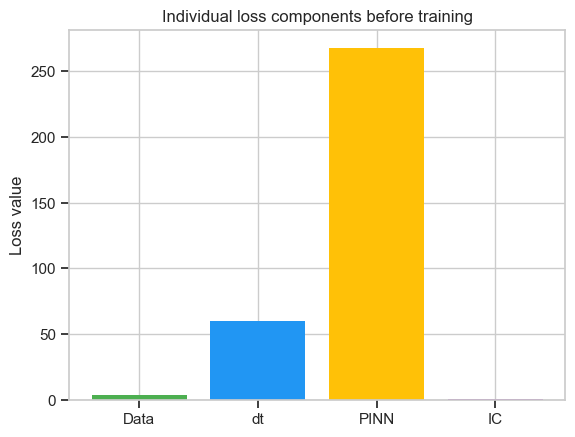

In [14]:
# --- Data loss (L_data) ---
y_pred = network.forward_pass(x_train)
L_data = network.criterion(y_pred, y_train)
print(f"L_data = {L_data.item():.4e}")

# --- Derivative loss (L_dt) ---
y_pred_dt, dy_dt_pred = network.calculate_autograd22(x_train)
dy_dt_true = network.calculate_from_ode(y_train)
L_dt_components = [network.criterion(dy_dt_pred[:, i], dy_dt_true[:, i]) for i in range(dy_dt_pred.shape[1])]
L_dt = torch.mean(torch.stack(L_dt_components))
print(f"L_dt = {L_dt.item():.4e}")

# --- Physics (collocation) loss (L_pinn) ---
dy_dt_col, dy_dt_col_true = network.calculate_point_grad2(x_col, None)
L_pinn_components = [network.criterion(dy_dt_col[:, i], dy_dt_col_true[:, i]) for i in range(dy_dt_col.shape[1])]
L_pinn = torch.mean(torch.stack(L_pinn_components))
print(f"L_pinn = {L_pinn.item():.4e}")

# --- Initial condition loss (L_ic) ---
y_ic_pred = network.forward_pass(x_ic)
L_ic = network.criterion(y_ic_pred, y_ic)
print(f"L_ic = {L_ic.item():.4e}")

# --- Total weighted loss ---
w_data, w_dt, w_pinn, w_ic = network.cfg.nn.weighting.weights
L_total = w_data * L_data + w_dt * L_dt + w_pinn * L_pinn + w_ic * L_ic
print("\nWeighted contributions:")
print(f"  w_data * L_data : {w_data * L_data:.4e}")
print(f"  w_dt   * L_dt   : {w_dt * L_dt:.4e}")
print(f"  w_pinn * L_pinn : {w_pinn * L_pinn:.4e}")
print(f"  w_ic   * L_ic   : {w_ic * L_ic:.4e}")
print(f"\nTotal weighted loss = {L_total.item():.4e}")

# --- Visualize contributions ---
plt.bar(["Data", "dt", "PINN", "IC"],
        [L_data.item(), L_dt.item(), L_pinn.item(), L_ic.item()],
        color=["#4CAF50", "#2196F3", "#FFC107", "#9C27B0"])
plt.ylabel("Loss value")
plt.title("Individual loss components before training")
%matplotlib inline
plt.show()

#### Dynamic Weighting Analysis

-> how PowerPINN dynamically adjusts the four loss weights during training using the class PINNWeighting.

In [15]:
weighting = PINNWeighting(network.model, network.cfg, network.device, network.output_dim, None)
print("Update scheme:", weighting.scheme)
print("Update frequency (epochs):", weighting.update_weights_freq)
print("Initial weights tensor:", weighting.weights.detach().cpu().numpy())

Weights initialized as:  [1, 0.001, 0.0001, 0.001]  are updated with scheme:  Static 
Update scheme: Static
Update frequency (epochs): 50
Initial weights tensor: [1.e+00 1.e-03 1.e-04 1.e-03]


In [16]:
# Initialize the weighting scheme manually (mimics what pinn_train2() does)
network.weighting_scheme = PINNWeighting(
    model=network.model,
    cfg=network.cfg,
    device=network.device,
    loss_dimension=network.output_dim,
    wandb_run=None   # disable wandb for notebook
)

Weights initialized as:  [1, 0.001, 0.0001, 0.001]  are updated with scheme:  Static 


Change weights to only consider data loss

In [17]:
config_nn.nn.weighting.weights = [1.0, 0.0, 0.0, 0.0]

#### Training Loop

Simulate a short training run to observe live loss evolution without running a full training session

Note: Optimizer temporarily switched to Adam (no closure required) - error running it differntly

In [18]:
def _to_dev32_req(t, device, requires_grad=False):
    if t is None:
        return None
    t = t.detach().to(device=device, dtype=torch.float32)
    if requires_grad:
        t.requires_grad_(True)
    return t.contiguous()

In [19]:
# Recreate LBFGS optimizer AFTER moving model
network.optimizer = optim.LBFGS(
    network.model.parameters(),
    lr=network.cfg.nn.lr,
    line_search_fn="strong_wolfe"
)

# choose preferred device
preferred_device = (
    torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cuda") if torch.cuda.is_available()
    else torch.device("cpu")
)

# 2) Prepare data on device (time needs gradients for PINN derivatives)
x_train = _to_dev32_req(x_train, preferred_device, requires_grad=True)
y_train = _to_dev32_req(y_train, preferred_device, requires_grad=False)
x_col   = _to_dev32_req(x_col,   preferred_device, requires_grad=True)
x_ic    = _to_dev32_req(x_ic,    preferred_device, requires_grad=True)
y_ic    = _to_dev32_req(y_ic,    preferred_device, requires_grad=False)
x_val   = _to_dev32_req(x_val,   preferred_device, requires_grad=True)
y_val   = _to_dev32_req(y_val,   preferred_device, requires_grad=False)

# 3) Quick device sanity checks
def _check_devices():
    ps = [p.device for p in network.model.parameters()]
    unique_param_devs = set(ps)
    print("Model param devices:", unique_param_devs)
    print("x_train:", x_train.device, "x_col:", x_col.device, "x_ic:", x_ic.device, "x_val:", x_val.device)

network.model = network.model.to(preferred_device)

_check_devices()

Model param devices: {device(type='mps', index=0)}
x_train: mps:0 x_col: mps:0 x_ic: mps:0 x_val: mps:0


In [21]:
# --- 1. Switch optimizer to LBFGS ---
network.optimizer = optim.LBFGS(
    network.model.parameters(),
    lr=network.cfg.nn.lr,
    line_search_fn="strong_wolfe"
)

# --- 2. Initialize weighting scheme manually (since we’re not calling pinn_train2) ---
network.cfg.nn.weighting.weights = [1.0, 0.0, 0.0, 0.0]
network.weighting_scheme = PINNWeighting(
    model=network.model,
    cfg=network.cfg,
    device=network.device,
    loss_dimension=network.output_dim,
    wandb_run=None
)

# --- 3. Reduce epochs for inspection ---
network.cfg.nn.num_epochs = 10
network.cfg.nn.early_stopping = False

# --- 4. Prepare loss logs ---
history = {"total": [], "data": [], "dt": [], "pinn": [], "ic": [], "val": []}

print(f"Starting short PowerPINN training loop (LBFGS), {network.cfg.nn.num_epochs} epochs on {network.device}...")

for epoch in range(network.cfg.nn.num_epochs):
    network.model.train()

    def closure():
        network.optimizer.zero_grad()

        # ---- Forward + compute individual losses ----
        output, dydt0, ode0 = network.calculate_point_grad2(x_train, y_train)
        dydt1, ode1 = network.calculate_point_grad2(x_col, None)
        output_ic = network.forward_pass(x_ic)

        loss_data = network.criterion(output, y_train)
        loss_dt_list = [network.criterion(dydt0[:, i], ode0[:, i]) for i in range(dydt0.shape[1])]
        loss_pinn_list = [network.criterion(dydt1[:, i], ode1[:, i]) for i in range(dydt1.shape[1])]
        loss_ic = network.criterion(output_ic, y_ic)

        # ---- Combine weighted total loss ----
        loss_total, _ = network.weighting_scheme.compute_weighted_loss(
            loss_data, loss_dt_list, loss_pinn_list, loss_ic, epoch
        )

        # --- persist for outside access ---
        network.loss_total = loss_total
        network.loss_data = loss_data
        network.loss_dt_list = loss_dt_list
        network.loss_pinn_list = loss_pinn_list
        network.loss_ic = loss_ic

        loss_total.backward()
        return loss_total


    # ---- LBFGS update (calls closure internally) ----
    network.optimizer.step(closure)

    # ---- Validation ----
    network.model.eval()

    # IMPORTANT: do NOT wrap this in torch.no_grad() because we need autograd for dt
    # Make sure validation inputs require gradients on the time column
    if not x_val.requires_grad:
        x_val = x_val.detach().clone().requires_grad_(True)

    # Compute outputs + physics terms with gradients enabled
    val_outputs, val_dydt, val_ode = network.calculate_point_grad2(x_val, y_val)

    # Now compute validation losses; after getting scalars you can .item() them
    val_loss_data = network.criterion(val_outputs, y_val)
    val_loss_physics = [network.criterion(val_dydt[:, i], val_ode[:, i]) for i in range(val_dydt.shape[1])]
    val_loss = val_loss_data.item() + torch.mean(torch.stack(val_loss_physics)).item()

    # (Optional) If you're worried about holding a graph between iterations:
    # explicitly detach anything you plan to store.
    val_outputs = val_outputs.detach()

    # ---- Log losses (note: loss_total may be tensor or float) ----
    network.optimizer.step(closure)

    loss_total_value = network.loss_total.item()
    history["total"].append(loss_total_value)
    history["data"].append(network.loss_data.item())
    history["dt"].append(torch.mean(torch.stack(network.loss_dt_list)).item())
    history["pinn"].append(torch.mean(torch.stack(network.loss_pinn_list)).item())
    history["ic"].append(network.loss_ic.item())
    history["val"].append(val_loss)

    print(f"Epoch {epoch+1:02d} | "
          f"L_total={history['total'][-1]:.4e}, "
          f"L_data={history['data'][-1]:.4e}, "
          f"L_dt={history['dt'][-1]:.4e}, "
          f"L_pinn={history['pinn'][-1]:.4e}, "
          f"L_ic={history['ic'][-1]:.4e}, "
          f"L_val={val_loss:.4e}")
    print(f"Epoch {epoch+1:02d} | Weights: {network.weighting_scheme.weights.detach().cpu().numpy()}")

print("Short LBFGS training loop finished")

Weights initialized as:  [1.0, 0.0, 0.0, 0.0]  are updated with scheme:  Static 
Starting short PowerPINN training loop (LBFGS), 10 epochs on mps...
Epoch 01 | L_total=2.5348e-01, L_data=2.5348e-01, L_dt=6.0367e+01, L_pinn=1.5833e+02, L_ic=2.1682e+00, L_val=5.8209e+01
Epoch 01 | Weights: [1. 0. 0. 0.]
Epoch 02 | L_total=1.7768e-01, L_data=1.7768e-01, L_dt=6.1907e+01, L_pinn=8.1737e+00, L_ic=3.3854e+00, L_val=6.0097e+01
Epoch 02 | Weights: [1. 0. 0. 0.]
Epoch 03 | L_total=1.6477e-01, L_data=1.6477e-01, L_dt=6.1568e+01, L_pinn=2.6794e+01, L_ic=3.2753e+00, L_val=5.9931e+01
Epoch 03 | Weights: [1. 0. 0. 0.]
Epoch 04 | L_total=1.2957e-01, L_data=1.2957e-01, L_dt=5.4954e+01, L_pinn=1.5614e+02, L_ic=2.7274e+00, L_val=5.8962e+01
Epoch 04 | Weights: [1. 0. 0. 0.]
Epoch 05 | L_total=6.7179e-02, L_data=6.7179e-02, L_dt=4.1257e+01, L_pinn=7.6862e+01, L_ic=1.4070e+00, L_val=4.8374e+01
Epoch 05 | Weights: [1. 0. 0. 0.]
Epoch 06 | L_total=2.7300e-02, L_data=2.7300e-02, L_dt=2.2280e+01, L_pinn=2.0057e

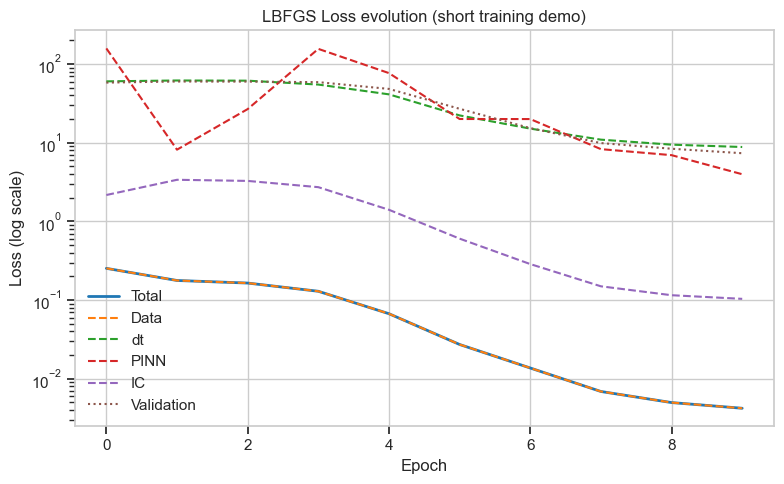

In [22]:
# --- 5. Plot loss evolution ---
plt.figure(figsize=(8,5))
plt.plot(history["total"], label="Total", linewidth=2)
plt.plot(history["data"], label="Data", linestyle="--")
plt.plot(history["dt"], label="dt", linestyle="--")
plt.plot(history["pinn"], label="PINN", linestyle="--")
plt.plot(history["ic"], label="IC", linestyle="--")
plt.plot(history["val"], label="Validation", linestyle=":")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss (log scale)")
plt.title("LBFGS Loss evolution (short training demo)")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
# --- Force DataSampler tensors to be on same device as model before training ---
def patch_define_train_val_data2_to_device(dl, device):
    orig_func = dl.define_train_val_data2

    def wrapped(*args, **kwargs):
        # Remove the first positional argument if it's 'self' passed again
        if len(args) and isinstance(args[0], type(dl)):
            args = args[1:]
        data = orig_func(*args, **kwargs)
        return tuple(t.to(device) if isinstance(t, torch.Tensor) else t for t in data)

    # Bind it correctly to the DataSampler instance
    dl.define_train_val_data2 = wrapped.__get__(dl, dl.__class__)

# Apply patch
patch_define_train_val_data2_to_device(network.data_loader, network.device)

In [21]:
# --- Configure simplified run ---
network.cfg.nn.optimizer = "LBFGS"
network.cfg.nn.num_epochs = 10
network.cfg.nn.early_stopping = False
network.cfg.nn.weighting.weights = [1.0, 0.0, 0.0, 0.0]  # only data loss
network.cfg.nn.batch_size = 128  # or e.g. len(x_train)

# --- Run PowerPINN training ---
print(f"Running PowerPINN LBFGS training on {network.device}...")
network.pinn_train2(
    num_of_skip_data_points=1,
    num_of_skip_col_points=1,
    num_of_skip_val_points=1,
    wandb_run=None
)

Running PowerPINN LBFGS training on mps...
Number of labeled training data: 40000 Number of collocation points: 500000 Number of collocation points (IC): 500 Number of validation data: 5000
Weights initialized as:  [1.0, 0.0, 0.0, 0.0]  are updated with scheme:  Static 
getting in training
Model( and tf values) saved: model/data/SM_AVR_GOVDynamicNN_1_10_40000_500000_5000_None_None_1.0_0.0_0.0_0.0_Static.pth
Total test trajectories 50
Loss: 0.16357844
MAE Loss: 0.22236702
Total trainable parameters 17929


In [ ]:
print(network.device)

(Next Planned) — Full Training and Logging

Next step after your meeting:
Integrate back into pinn_train2() for a complete training run with
	•	LBFGS optimizer and closure
	•	early stopping
	•	checkpoint saving
	•	wandb logging

Open Questions
- how to use lbfgs, what is closure?
- where do I specify what dataset I use?